In [18]:
import pandas as pd
import glob

# --- Get all AML files ---
aml_files = glob.glob("/Users/ej/Desktop/Applied Ocean Observation Technologies/AML/AML Data/*.csv")

# --- Load and combine ---
aml_list = []

for file in aml_files:
    df = pd.read_csv(file)
    aml_list.append(df)

aml = pd.concat(aml_list, ignore_index=True)

# --- Check columns ---
print(aml.columns)

Index(['ID', ' Lon', ' Lat', ' Date', 'Time', 'Cond', 'ADC', 'TempCT', 'ADC.1',
       'Pressure', 'ADC.2', 'DO', 'TempDO', 'DOM', 'ADC.3', 'Chloro-blue',
       'ADC.4', 'Turbidity', 'ADC.5', 'analog', 'ADC.6', 'Salinity', 'Density',
       'Depth'],
      dtype='object')


In [19]:
depth_aml = aml["Depth"].values
chla = aml["Chloro-blue"].values

In [20]:
# Round depth to 1 m bins (change if needed)
aml["depth_bin"] = aml["Depth"].round(1)

# Average within each bin
# Keep only numeric columns
aml_numeric = aml.select_dtypes(include='number')

# Add depth_bin back
aml_numeric["depth_bin"] = aml["depth_bin"]

# Group and average
aml_binned = aml_numeric.groupby("depth_bin").mean().reset_index()


depth_aml = aml_binned["depth_bin"].values
chla = aml_binned["Chloro-blue"].values
aml = aml.sort_values("Depth")

In [21]:
print(aml.dtypes)

ID              object
 Lon            object
 Lat            object
 Date           object
Time            object
Cond           float64
ADC              int64
TempCT         float64
ADC.1            int64
Pressure       float64
ADC.2          float64
DO             float64
TempDO         float64
DOM            float64
ADC.3          float64
Chloro-blue    float64
ADC.4            int64
Turbidity      float64
ADC.5            int64
analog           int64
ADC.6            int64
Salinity       float64
Density        float64
Depth          float64
depth_bin      float64
dtype: object


In [22]:
print(aml_binned.head())
print(aml_binned.columns)

   depth_bin       Cond           ADC     TempCT          ADC.1  Pressure  \
0        0.5  15.087913  20883.565217  15.635522  287921.086957  0.523238   
1        0.6  15.369541  21262.891892  15.656149  288205.270270  0.613539   
2        0.7  15.379125  21275.777778  15.671569  288417.027778  0.714669   
3        0.8  15.349882  21236.427948  15.666463  288346.139738  0.813904   
4        0.9  15.276296  21137.307463  15.588955  287277.859701  0.911330   

           ADC.2          DO     TempDO       DOM         ADC.3  Chloro-blue  \
0  836742.347826  297.458261  15.246957  4.273478  2.190948e+06     0.905652   
1  837945.972973  296.032027  15.553243  4.661892  2.403012e+06     0.794730   
2  839293.944444  295.748542  15.660556  4.727569  2.436670e+06     0.774583   
3  840616.655022  295.919782  15.653100  4.818559  2.484342e+06     0.792882   
4  841915.256716  296.647075  15.585403  4.911672  2.532412e+06     0.803612   

          ADC.4  Turbidity         ADC.5  analog        

In [23]:
depth_aml = aml_binned["depth_bin"].values
chla = aml_binned["Chloro-blue"].values

In [24]:
ek80_df = pd.read_csv("/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/LSSS stuff.txt", delim_whitespace=True)

print(ek80_df.columns)
print(ek80_df.dtypes)

Index(['YEAR', 'MO', 'DA', 'UTC', 'LOG1', 'LOG2', 'LATITUDE', 'LONGITUD',
       'BDMIN', 'BDMAX', 'OBJECT', 'CH', 'PDMIN', 'PDMAX', 'PDMEAN', 'UPINLM',
       'OTHER', 'WHITE', 'He/Sp', 'TOTAL'],
      dtype='object')
YEAR          int64
MO            int64
DA            int64
UTC          object
LOG1        float64
LOG2        float64
LATITUDE    float64
LONGITUD    float64
BDMIN       float64
BDMAX       float64
OBJECT        int64
CH            int64
PDMIN         int64
PDMAX         int64
PDMEAN      float64
UPINLM      float64
OTHER       float64
WHITE       float64
He/Sp       float64
TOTAL       float64
dtype: object


/var/folders/qs/ttgn3ynj6wg2szkpcdfbj0c40000gn/T/ipykernel_63814/4033416688.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  ek80_df = pd.read_csv("/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/LSSS stuff.txt", delim_whitespace=True)


In [25]:
depth_ek80 = ek80_df["BDMIN"].values
ek80 = ek80_df["TOTAL"].values

In [26]:
ek80_df = ek80_df.sort_values("BDMIN")

depth_ek80 = ek80_df["BDMIN"].values
ek80 = ek80_df["TOTAL"].values

In [27]:
from scipy.interpolate import interp1d

interp_func = interp1d(
    depth_ek80,
    ek80,
    bounds_error=False,
    fill_value="extrapolate"
)

ek80_interp = interp_func(depth_aml)

/opt/anaconda3/envs/ocean/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/ocean/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


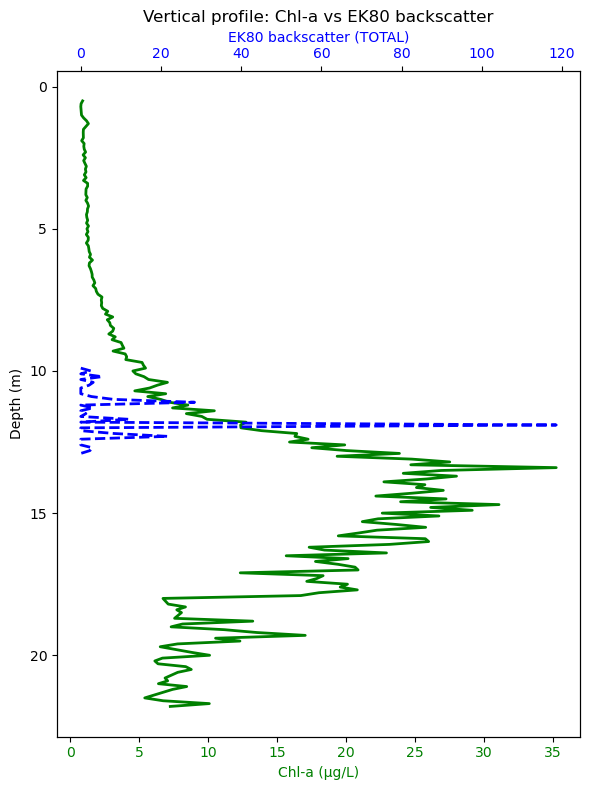

In [28]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(6, 8))

# --- AML ---
ax1.plot(chla, depth_aml, color='green', linewidth=2, label='Chl-a')
ax1.set_xlabel('Chl-a (µg/L)', color='green')
ax1.set_ylabel('Depth (m)')
ax1.tick_params(axis='x', labelcolor='green')
ax1.invert_yaxis()

# --- EK80 ---
ax2 = ax1.twiny()
ax2.plot(ek80_interp, depth_aml, color='blue', linestyle='--', linewidth=2, label='EK80')
ax2.set_xlabel('EK80 backscatter (TOTAL)', color='blue')
ax2.tick_params(axis='x', labelcolor='blue')

plt.title('Vertical profile: Chl-a vs EK80 backscatter')
plt.tight_layout()
plt.show()

In [29]:
print(min(depth_ek80), max(depth_ek80))
print(min(depth_aml), max(depth_aml))

9.8 12.9
0.5 21.8


/opt/anaconda3/envs/ocean/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/ocean/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


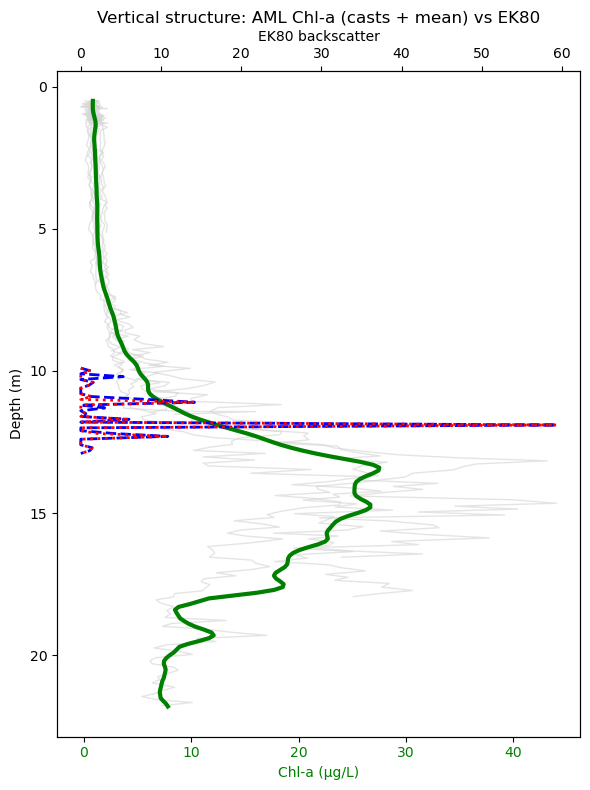

In [31]:
import pandas as pd
import glob
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

# -----------------------
# LOAD AML FILES
# -----------------------
aml_files = sorted(glob.glob("/Users/ej/Desktop/Applied Ocean Observation Technologies/AML/AML Data/*.csv"))

fig, ax1 = plt.subplots(figsize=(6, 8))

all_profiles = []

# --- Plot individual casts (thin grey) ---
for file in aml_files:
    df = pd.read_csv(file)

    # Adjust column names if needed
    depth = df["Depth"].values
    chla = df["Chloro-blue"].values

    # Sort just in case
    idx = depth.argsort()
    depth = depth[idx]
    chla = chla[idx]

    ax1.plot(chla, depth, color='lightgrey', linewidth=1, alpha=0.6)

    all_profiles.append(pd.DataFrame({
        "Depth": depth,
        "Chl": chla
    }))

# -----------------------
# COMBINE + BIN FOR MEAN
# -----------------------
aml_all = pd.concat(all_profiles, ignore_index=True)

aml_all["depth_bin"] = aml_all["Depth"].round(1)

aml_binned = aml_all.groupby("depth_bin").mean().reset_index()

depth_aml = aml_binned["depth_bin"].values
chla_mean = aml_binned["Chl"].values

# Smooth mean
chla_smooth = gaussian_filter1d(chla_mean, sigma=2)

# --- Plot mean profile ---
ax1.plot(chla_smooth, depth_aml, color='green', linewidth=3, label='Mean Chl-a')

ax1.set_xlabel('Chl-a (µg/L)', color='green')
ax1.set_ylabel('Depth (m)')
ax1.tick_params(axis='x', labelcolor='green')
ax1.invert_yaxis()

# -----------------------
# LOAD + PROCESS EK80
# -----------------------
ek80_df = pd.read_csv("/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/LSSS stuff.txt", sep='\s+')

ek80_df = ek80_df.sort_values("BDMIN")

depth_ek80 = ek80_df["BDMIN"].values
herring_sprat = ek80_df["He/Sp"].values
whiting = ek80_df["WHITE"].values


# Interpolate to AML depth
interp_hs = interp1d(depth_ek80, herring_sprat, bounds_error=False, fill_value="extrapolate")
hs_interp = interp_hs(depth_aml)

interp_wh = interp1d(depth_ek80, whiting, bounds_error=False, fill_value="extrapolate")
wh_interp = interp_wh(depth_aml)

# Remove duplicate depth entries (important!)
unique_mask = ~pd.Series(depth_ek80).duplicated()

depth_ek80 = depth_ek80[unique_mask]
herring_sprat = herring_sprat[unique_mask]
whiting = whiting[unique_mask]

# -----------------------
# PLOT EK80
# -----------------------
ax2 = ax1.twiny()

# ONLY fish groups
ax2.plot(hs_interp, depth_aml, color='blue', linestyle='--', linewidth=2, label='Herring/Sprat')
ax2.plot(wh_interp, depth_aml, color='red', linestyle=':', linewidth=2, label='Whiting')

ax2.set_xlabel('EK80 backscatter')
ax2.tick_params(axis='x')



plt.title('Vertical structure: AML Chl-a (casts + mean) vs EK80')

plt.tight_layout()
plt.show()

In [32]:
print(np.nanmin(herring_sprat), np.nanmax(herring_sprat))

0.0 59.2811


In [33]:
lsss_files = [
    "//Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/LSSS stuff.txt",
    "/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/ListUserFile16__F038000_T1_L3515.1-3521.6.txt",
    "/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/ListUserFile16__F038000_T1_L3487.5-3494.0.txt"
]

labels = ["Day 1", "Day 2", "Day 3"]
colors_hs = ["blue", "royalblue", "navy"]
colors_wh = ["red", "salmon", "darkred"]

In [41]:
import os

for f in lsss_files:
    print(f, os.path.exists(f))

import numpy as np

hs_all = []
wh_all = []

//Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/LSSS stuff.txt True
/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/ListUserFile16__F038000_T1_L3515.1-3521.6.txt True
/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/ListUserFile16__F038000_T1_L3487.5-3494.0.txt True


/opt/anaconda3/envs/ocean/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/ocean/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:482: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/opt/anaconda3/envs/ocean/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/ocean/lib/python3.10/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


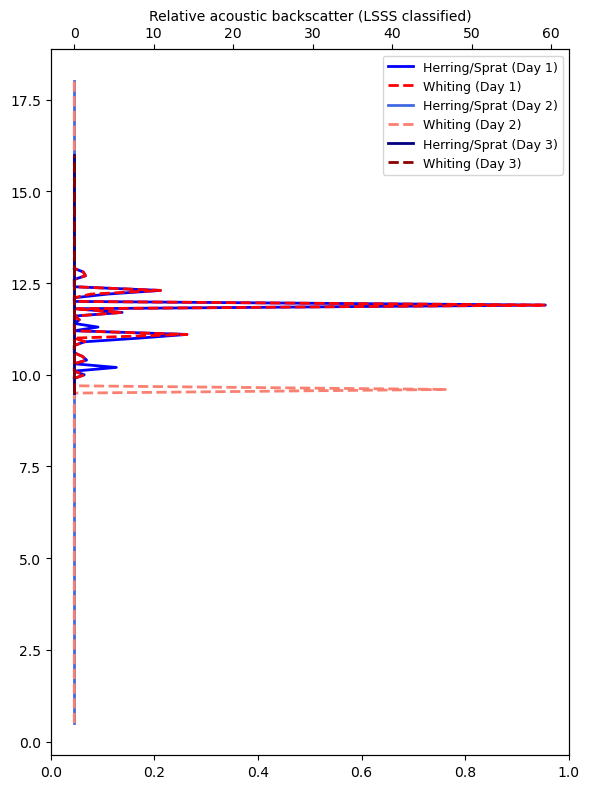

In [40]:
from scipy.interpolate import interp1d
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots(figsize=(6, 8))

ax2 = ax1.twiny()

for i, file in enumerate(lsss_files):

    # Load LSSS file
    ek80_df = pd.read_csv(file, sep='\s+')

    # Sort by depth (keep your structure)
    ek80_df = ek80_df.sort_values("BDMIN")

    depth_ek80 = ek80_df["BDMIN"].values

    # Extract species
    herring_sprat = ek80_df["He/Sp"].values
    whiting = ek80_df["WHITE"].values

    # Interpolate (same structure as you already use)
    interp_hs = interp1d(depth_ek80, herring_sprat,
                         bounds_error=False, fill_value="extrapolate")
    hs_interp = interp_hs(depth_aml)

    interp_wh = interp1d(depth_ek80, whiting,
                         bounds_error=False, fill_value="extrapolate")
    wh_interp = interp_wh(depth_aml)

    # Plot
    ax2.plot(hs_interp, depth_aml,
             color=colors_hs[i],
             linestyle='-',
             linewidth=2,
             label=f'Herring/Sprat ({labels[i]})')

    ax2.plot(wh_interp, depth_aml,
             color=colors_wh[i],
             linestyle='--',
             linewidth=2,
             label=f'Whiting ({labels[i]})')
    
ax2.set_xlabel('Relative acoustic backscatter (LSSS classified)')
ax2.tick_params(axis='x')

# Clean legend
ax2.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

In [72]:
import pandas as pd
from scipy.interpolate import interp1d

for file in lsss_files:

    ek80_df = pd.read_csv(file, sep='\s+')

    # Sort depth
    ek80_df = ek80_df.sort_values("BDMIN")

    # Remove duplicates (IMPORTANT)
    ek80_grouped = ek80_df.groupby("BDMIN").mean(numeric_only=True).reset_index()

    depth_ek80 = ek80_grouped["BDMIN"].values
    herring_sprat = ek80_grouped["He/Sp"].values
    whiting = ek80_grouped["WHITE"].values

   # Create empty profiles at AML depths
    hs_interp = np.zeros_like(depth_aml)
    wh_interp = np.zeros_like(depth_aml)

    # Assign values to nearest depth
    for i, d in enumerate(depth_ek80):
        idx = np.abs(depth_aml - d).argmin()
        hs_interp[idx] = herring_sprat[i]
        wh_interp[idx] = whiting[i]

    # ✅ NOW convert NaNs → 0 (THIS is the key fix)
    hs_interp = np.nan_to_num(hs_interp, nan=0.0)
    wh_interp = np.nan_to_num(wh_interp, nan=0.0)


    # Store
    hs_all.append(hs_interp)
    wh_all.append(wh_interp)

In [73]:
hs_mean = np.nanmean(hs_all, axis=0)
wh_mean = np.nanmean(wh_all, axis=0)

In [74]:
ax2 = ax1.twiny()

ax2.plot(hs_mean, depth_aml,
         color='blue', linewidth=2.5,
         label='Herring/Sprat')

ax2.plot(wh_mean, depth_aml,
         color='red', linewidth=2.5,
         linestyle='--',
         label='Whiting')

ax2.set_xlabel('Relative acoustic backscatter (LSSS classified)')
ax2.tick_params(axis='x')

ax2.legend(loc='upper right')

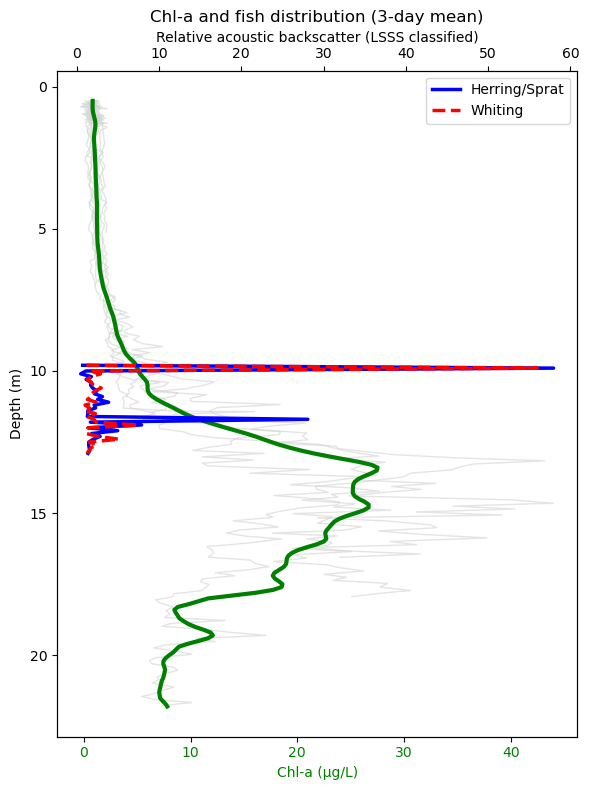

In [75]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d

# -----------------------
# LOAD AML FILES
# -----------------------
aml_files = sorted(glob.glob("/Users/ej/Desktop/Applied Ocean Observation Technologies/AML/AML Data/*.csv"))

fig, ax1 = plt.subplots(figsize=(6, 8))

all_profiles = []

# --- Plot individual casts (thin grey) ---
for file in aml_files:
    df = pd.read_csv(file)

    # Adjust column names if needed
    depth = df["Depth"].values
    chla = df["Chloro-blue"].values

    # Sort just in case
    idx = depth.argsort()
    depth = depth[idx]
    chla = chla[idx]

    ax1.plot(chla, depth, color='lightgrey', linewidth=1, alpha=0.6)

    all_profiles.append(pd.DataFrame({
        "Depth": depth,
        "Chl": chla
    }))

# -----------------------
# COMBINE + BIN FOR MEAN
# -----------------------
aml_all = pd.concat(all_profiles, ignore_index=True)

aml_all["depth_bin"] = aml_all["Depth"].round(1)

aml_binned = aml_all.groupby("depth_bin").mean().reset_index()

depth_aml = aml_binned["depth_bin"].values
chla_mean = aml_binned["Chl"].values

# Smooth mean
chla_smooth = gaussian_filter1d(chla_mean, sigma=2)

# --- Plot mean profile ---
ax1.plot(chla_smooth, depth_aml, color='green', linewidth=3, label='Mean Chl-a')

ax1.set_xlabel('Chl-a (µg/L)', color='green')
ax1.set_ylabel('Depth (m)')
ax1.tick_params(axis='x', labelcolor='green')
ax1.invert_yaxis()

# -----------------------
# PLOT LSSS
# -----------------------
ax2 = ax1.twiny()

ax2.plot(hs_mean, depth_aml,
         color='blue', linewidth=2.5,
         label='Herring/Sprat')

ax2.plot(wh_mean, depth_aml,
         color='red', linestyle='--',
         linewidth=2.5,
         label='Whiting')

ax2.set_xlabel('Relative acoustic backscatter (LSSS classified)')
ax2.tick_params(axis='x')

# Legend
ax2.legend(loc='upper right')

# -----------------------
# FINAL LAYOUT
# -----------------------
plt.title('Chl-a and fish distribution (3-day mean)')
plt.tight_layout()
plt.show()

/var/folders/qs/ttgn3ynj6wg2szkpcdfbj0c40000gn/T/ipykernel_63814/3081040899.py:111: RuntimeWarning: Mean of empty slice
  hs_mean = np.nanmean(hs_masked, axis=0)
/var/folders/qs/ttgn3ynj6wg2szkpcdfbj0c40000gn/T/ipykernel_63814/3081040899.py:112: RuntimeWarning: Mean of empty slice
  wh_mean = np.nanmean(wh_masked, axis=0)


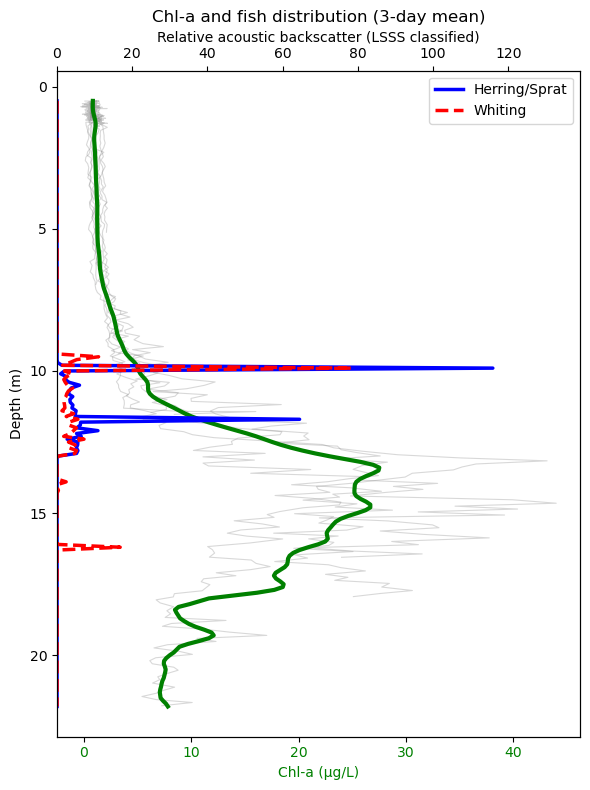

In [81]:
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# -----------------------
# LOAD AML FILES
# -----------------------
aml_files = sorted(glob.glob("/Users/ej/Desktop/Applied Ocean Observation Technologies/AML/AML Data/*.csv"))

fig, ax1 = plt.subplots(figsize=(6, 8))

all_profiles = []

for file in aml_files:
    df = pd.read_csv(file)

    depth = df["Depth"].values
    chla = df["Chloro-blue"].values

    # sort
    idx = depth.argsort()
    depth = depth[idx]
    chla = chla[idx]

    # grey individual casts
    ax1.plot(chla, depth, color='grey', alpha=0.3, linewidth=0.8)

    all_profiles.append(pd.DataFrame({
        "Depth": depth,
        "Chl": chla
    }))

# -----------------------
# AML MEAN PROFILE
# -----------------------
aml_all = pd.concat(all_profiles, ignore_index=True)

aml_all["depth_bin"] = aml_all["Depth"].round(1)

aml_binned = aml_all.groupby("depth_bin").mean().reset_index()

depth_aml = aml_binned["depth_bin"].values
chla_mean = aml_binned["Chl"].values

# smooth mean
chla_smooth = gaussian_filter1d(chla_mean, sigma=2)

# plot mean
ax1.plot(chla_smooth, depth_aml, color='green', linewidth=3, label="Mean Chl-a")

ax1.set_xlabel("Chl-a (µg/L)", color='green')
ax1.set_ylabel("Depth (m)")
ax1.tick_params(axis='x', labelcolor='green')
ax1.invert_yaxis()


# -----------------------
# LOAD LSSS FILES
# -----------------------
lsss_files = [
    "/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/LSSS stuff.txt",
    "/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/ListUserFile16__F038000_T1_L3515.1-3521.6.txt",
    "/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/ListUserFile16__F038000_T1_L3487.5-3494.0.txt"
]

hs_all = []
wh_all = []

for file in lsss_files:

    ek80_df = pd.read_csv(file, sep='\s+')
    ek80_df = ek80_df.sort_values("BDMIN")

    # ✅ remove duplicate depths properly
    ek80_df = ek80_df.groupby("BDMIN").mean(numeric_only=True).reset_index()

    depth_ek80 = ek80_df["BDMIN"].values
    hs = ek80_df["He/Sp"].values
    wh = ek80_df["WHITE"].values

    # ✅ create empty profiles at AML depth
    hs_profile = np.zeros_like(depth_aml)
    wh_profile = np.zeros_like(depth_aml)

    # ✅ map values to nearest depth (NO interpolation)
    for d, hs_val, wh_val in zip(depth_ek80, hs, wh):

        idx = np.abs(depth_aml - d).argmin()

        # take max to avoid overwriting
        hs_profile[idx] = max(hs_profile[idx], hs_val)
        wh_profile[idx] = max(wh_profile[idx], wh_val)

    hs_all.append(hs_profile)
    wh_all.append(wh_profile)

# -----------------------
# COMBINE DAYS (NO SMEARING)
# -----------------------
hs_all = np.array(hs_all)
wh_all = np.array(wh_all)


# ✅ only average where signal exists
hs_masked = np.where(hs_all > 0, hs_all, np.nan)
wh_masked = np.where(wh_all > 0, wh_all, np.nan)


hs_mean = np.nanmean(hs_masked, axis=0)
wh_mean = np.nanmean(wh_masked, axis=0)

# ✅ bring back zero baseline
hs_mean = np.nan_to_num(hs_mean, nan=0.0)
wh_mean = np.nan_to_num(wh_mean, nan=0.0)


# -----------------------
# PLOT LSSS
# -----------------------
ax2 = ax1.twiny()

ax2.plot(hs_mean, depth_aml, color='blue', linewidth=2.5, label="Herring/Sprat")
ax2.plot(wh_mean, depth_aml, color='red', linestyle='--', linewidth=2.5, label="Whiting")

ax2.set_xlabel("Relative acoustic backscatter (LSSS classified)")
ax2.tick_params(axis='x')

# optional scaling
ax2.set_xlim(0, np.max(hs_mean) * 1.2)

ax2.legend(loc="upper right")


# -----------------------
# FINAL LAYOUT
# -----------------------
plt.title("Chl-a and fish distribution (3-day mean)")
plt.tight_layout()
plt.show()

In [86]:
thermocline_depths = []

for file in lsss_files:
    ek80_df = pd.read_csv(file, sep='\s+')
    ek80_df = ek80_df.sort_values("BDMIN")

    ek80_df = ek80_df.groupby("BDMIN").mean(numeric_only=True).reset_index()

    depth = ek80_df["BDMIN"].values
    other = ek80_df["OTHER"].values

    # depth of max "OTHER" signal
    therm_depth = depth[np.argmax(other)]
    thermocline_depths.append(therm_depth)

# average across days
thermocline_depth = np.mean(thermocline_depths)

In [87]:
hs_mean
wh_mean
depth_lsss = all_depths

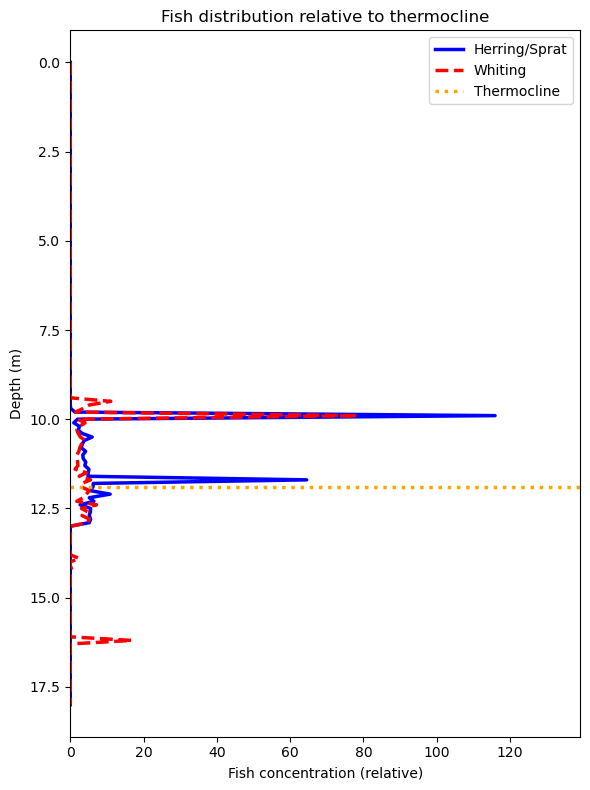

In [88]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 8))

# Fish profiles
ax.plot(hs_mean, depth_lsss, color='blue', linewidth=2.5, label="Herring/Sprat")
ax.plot(wh_mean, depth_lsss, color='red', linestyle='--', linewidth=2.5, label="Whiting")

# Thermocline as horizontal line
ax.axhline(thermocline_depth,
           color='orange',
           linestyle=':',
           linewidth=2.5,
           label='Thermocline')

# Axes
ax.set_xlabel("Fish concentration (relative)")
ax.set_ylabel("Depth (m)")
ax.invert_yaxis()

# Nice limits
ax.set_xlim(0, max(hs_mean) * 1.2)

# Legend
ax.legend(loc='upper right')

plt.title("Fish distribution relative to thermocline")
plt.tight_layout()
plt.show()

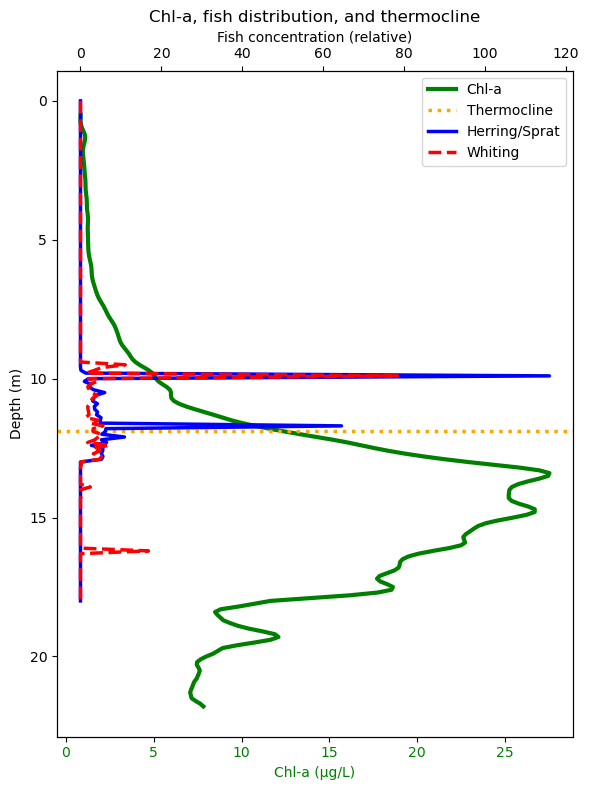

In [89]:
fig, ax1 = plt.subplots(figsize=(6, 8))

# -----------------------
# CHL-A (AML)  ✅
# -----------------------
ax1.plot(chla_smooth, depth_aml,
         color='green', linewidth=3,
         label="Chl-a")

ax1.set_xlabel("Chl-a (µg/L)", color='green')
ax1.tick_params(axis='x', labelcolor='green')

# -----------------------
# FISH (LSSS) ✅
# -----------------------
ax2 = ax1.twiny()

ax2.plot(hs_mean, depth_lsss,
         color='blue', linewidth=2.5,
         label="Herring/Sprat")

ax2.plot(wh_mean, depth_lsss,
         color='red', linestyle='--',
         linewidth=2.5,
         label="Whiting")

ax2.set_xlabel("Fish concentration (relative)")
ax2.tick_params(axis='x')

# -----------------------
# THERMOCLINE ✅
# -----------------------
ax1.axhline(thermocline_depth,
            color='orange',
            linestyle=':',
            linewidth=2.5,
            label='Thermocline')

# -----------------------
# DEPTH AXIS ✅
# -----------------------
ax1.set_ylabel("Depth (m)")
ax1.invert_yaxis()

# -----------------------
# LEGEND ✅ (combine both axes)
# -----------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# -----------------------
# FINAL
# -----------------------
plt.title("Chl-a, fish distribution, and thermocline")
plt.tight_layout()
plt.show()

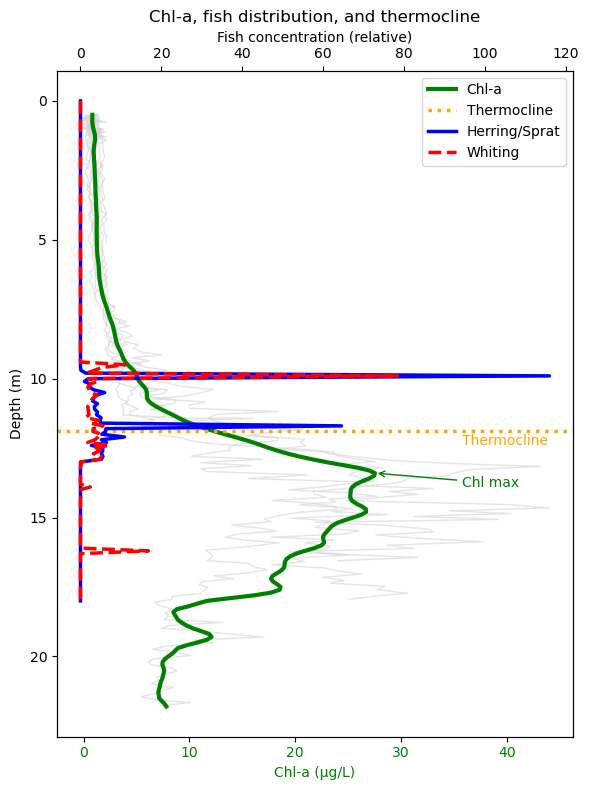

In [107]:
fig, ax1 = plt.subplots(figsize=(6, 8))

# -----------------------
# AML INDIVIDUAL PROFILES (background)
# -----------------------
for file in aml_files:
    df = pd.read_csv(file)

    # Adjust column names if needed
    depth = df["Depth"].values
    chla = df["Chloro-blue"].values

    # Sort just in case
    idx = depth.argsort()
    depth = depth[idx]
    chla = chla[idx]

    ax1.plot(chla, depth, color='lightgrey', linewidth=1, alpha=0.6)

    all_profiles.append(pd.DataFrame({
        "Depth": depth,
        "Chl": chla
    }))

# -----------------------
# AML MEAN (foreground)
# -----------------------
ax1.plot(chla_smooth, depth_aml,
         color='green',
         linewidth=3,
         label="Chl-a")


ax1.set_xlabel("Chl-a (µg/L)", color='green')
ax1.tick_params(axis='x', labelcolor='green')

# -----------------------
# FISH (LSSS)
# -----------------------
ax2 = ax1.twiny()

ax2.plot(hs_mean, depth_lsss,
         color='blue',
         linewidth=2.5,
         label="Herring/Sprat")

ax2.plot(wh_mean, depth_lsss,
         color='red',
         linestyle='--',
         linewidth=2.5,
         label="Whiting")


ax2.set_xlabel("Fish concentration (relative)")
ax2.tick_params(axis='x')

# -----------------------
# THERMOCLINE
# -----------------------
ax1.axhline(thermocline_depth,
            color='orange',
            linestyle=':',
            linewidth=2.5,
            label='Thermocline')

# -----------------------
# DEPTH AXIS
# -----------------------
ax1.set_ylabel("Depth (m)")
ax1.invert_yaxis()

# -----------------------
# LEGEND (combine both axes)
# -----------------------
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()



ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

# --- Chl max ---
chl_max_depth = depth_aml[np.argmax(chla_smooth)]

ax1.annotate(
    'Chl max',
    xy=(chla_smooth.max(), chl_max_depth),
    xytext=(chla_smooth.max()*1.3, chl_max_depth+0.5),
    arrowprops=dict(arrowstyle='->', color='green'),
    color='green',
    fontsize=10
)



# --- Thermocline ---
ax1.annotate(
    'Thermocline',
    xy=(chla_smooth.max()*0.6, thermocline_depth),
    xytext=(chla_smooth.max()*1.3, thermocline_depth+0.5),
    color='orange',
    fontsize=10
)


# -----------------------
# FINAL
# -----------------------
ax.axhline(chl_max_depth, color='green', linestyle='--', alpha=0.4)
ax.axhline(fish_layer_depth, color='blue', linestyle='--', alpha=0.4)

plt.title("Chl-a, fish distribution, and thermocline")
plt.tight_layout()
plt.show()

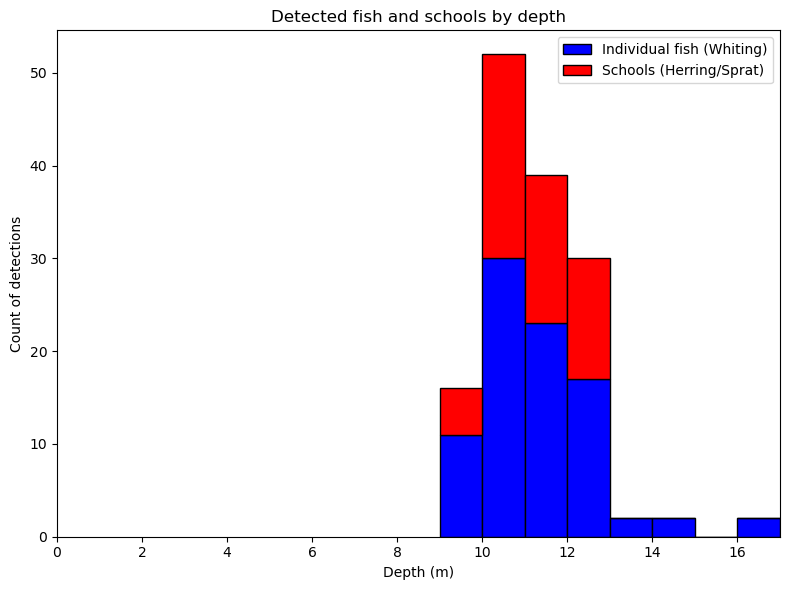

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# LSSS FILES
# -----------------------
lsss_files = [
    "/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/LSSS stuff.txt",
    "/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/ListUserFile16__F038000_T1_L3515.1-3521.6.txt",
    "/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/ListUserFile16__F038000_T1_L3487.5-3494.0.txt"
]

# -----------------------
# COLLECT DEPTHS
# -----------------------
depth_hs = []   # herring/sprat (schools)
depth_wh = []   # whiting (individual)

for file in lsss_files:

    ek80_df = pd.read_csv(file, sep='\s+')
    ek80_df = ek80_df.sort_values("BDMIN")

    # average duplicate depths
    ek80_df = ek80_df.groupby("BDMIN").mean(numeric_only=True).reset_index()

    depth = ek80_df["BDMIN"].values
    hs = ek80_df["He/Sp"].values
    wh = ek80_df["WHITE"].values

    # collect depths where signal exists
    depth_hs.extend(depth[hs > 0])
    depth_wh.extend(depth[wh > 0])

depth_hs = np.array(depth_hs)
depth_wh = np.array(depth_wh)

# -----------------------
# HISTOGRAM BINS
# -----------------------
bins = np.arange(np.floor(min(depth_hs.min(), depth_wh.min())),
                 np.ceil(max(depth_hs.max(), depth_wh.max())) + 1,
                 1)  # 1 m bins

# -----------------------
# PLOT
# -----------------------
plt.figure(figsize=(8, 6))

plt.hist([depth_wh, depth_hs],
         bins=bins,
         stacked=True,
         color=['blue', 'red'],
         label=['Individual fish (Whiting)', 'Schools (Herring/Sprat)'],
         edgecolor='black')

plt.xlabel("Depth (m)")
plt.ylabel("Count of detections")
plt.title("Detected fish and schools by depth")

plt.legend()

# ✅ make depth start at 0 and increase right
plt.xlim(0, bins.max())

plt.tight_layout()
plt.show()

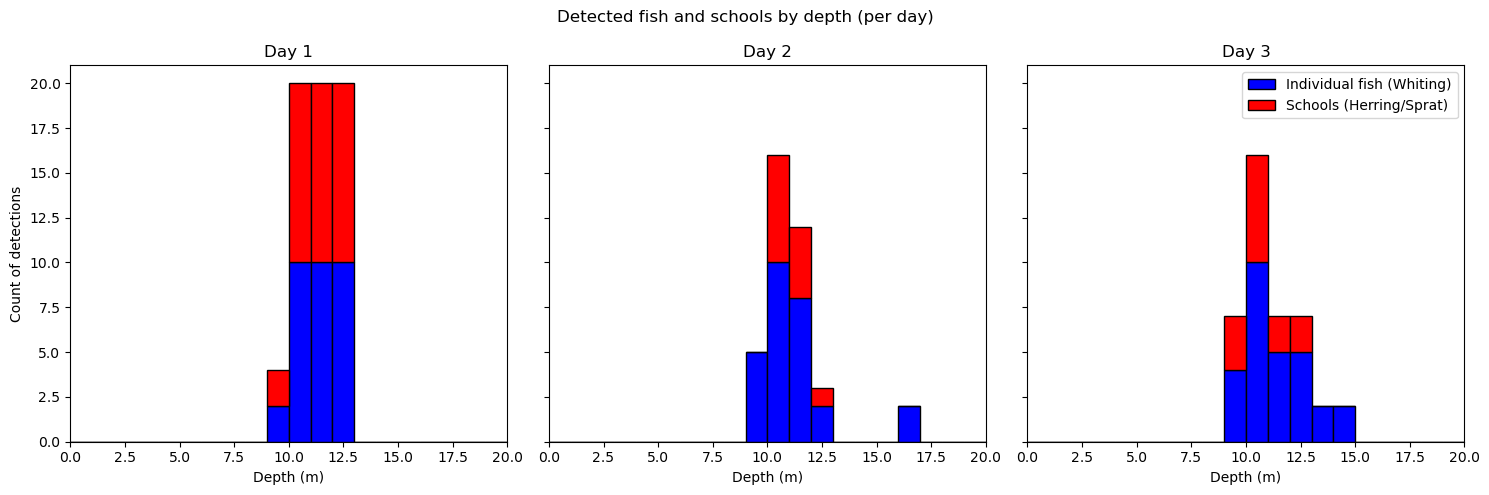

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------
# LSSS FILES + LABELS
# -----------------------
lsss_files = [
    "/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/LSSS stuff.txt",
    "/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/ListUserFile16__F038000_T1_L3515.1-3521.6.txt",
    "/Users/ej/Desktop/Applied Ocean Observation Technologies/LSSS/ListUserFile16__F038000_T1_L3487.5-3494.0.txt"
]

labels = ["Day 1", "Day 2", "Day 3"]

# -----------------------
# CREATE SUBPLOTS
# -----------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# -----------------------
# LOOP OVER DAYS
# -----------------------
for i, file in enumerate(lsss_files):

    ek80_df = pd.read_csv(file, sep='\s+')
    ek80_df = ek80_df.sort_values("BDMIN")

    # average duplicate depths
    ek80_df = ek80_df.groupby("BDMIN").mean(numeric_only=True).reset_index()

    depth = ek80_df["BDMIN"].values
    hs = ek80_df["He/Sp"].values
    wh = ek80_df["WHITE"].values

    # filter depths where signal exists
    depth_hs = depth[hs > 0]
    depth_wh = depth[wh > 0]

    # bins (same for all panels)
    bins = np.arange(0, 30, 1)

    # plot histogram
    axes[i].hist(
        [depth_wh, depth_hs],
        bins=bins,
        stacked=True,
        color=['blue', 'red'],
        edgecolor='black'
    )

    axes[i].set_title(labels[i])
    axes[i].set_xlabel("Depth (m)")
    axes[i].set_xlim(0, 20)

# shared y-axis
axes[0].set_ylabel("Count of detections")

# legend (only once)
axes[-1].legend(
    ['Individual fish (Whiting)', 'Schools (Herring/Sprat)'],
    loc='upper right'
)

plt.suptitle("Detected fish and schools by depth (per day)")
plt.tight_layout()
plt.show()